# Introduction
This Coursera Lab Jupyter notebook implements a Kalman filter for the spring-mass-damper system.

Don't forget that to execute the Octave code in any cell, depress the "shift" and "enter" keys on your keyboard at the same time, making sure that your cursor is placed inside of the code cell. I refer to this as "< shift \> < enter \>" in my instructions below.

### Defining the constants and setting up the problem
The next notebook cell loads the state-space model and the dataset from simulating the model. Place the cursor inside the cell and depress < shift > < enter >. Do the same for the following cells to execute their contents.

In [1]:
% Load data from simulation of system dynamic model. These data were created by the code in 
% Lesson 1.4.2, and are the same data used in Lesson 1.4.3.
%
% Data file contains Ad Bd Cd Dd SigmaV SigmaW dT t u x z
load readonly/simOut.mat

### Run the linear Kalman filter using the data loaded from "simOut.mat"
The next notebook cell runs the Kalman filter.

In [2]:
[nx,nt] = size(x);
xhat = zeros(nx,1);        % Initialize state estimate at time zero
SigmaX = zeros(nx,nx);     %  and its covariance matrix
xhatstore = zeros(nx,nt);  % Reserve storage for all state estimates
boundstore = zeros(nx,nt); %  and their confidence bounds

for k = 2:nt               % Execute the Kalman filter
  % KF Step 1a: State estimate time update      
  xhat = Ad*xhat + Bd*u(k-1); % use prior value of "u"
 
  % KF Step 1b: Error covariance time update   
  SigmaX = Ad*SigmaX*Ad' + SigmaW;
  
  % KF Step 1c: Estimate system output   
  zhat = Cd*xhat + Dd*u(k); % use present value of "u"

  % KF Step 2a: Compute Kalman gain matrix   
  L = SigmaX*Cd'/(Cd*SigmaX*Cd' + SigmaV); 
 
  % KF Step 2b: State estimate measurement update   
  xhat = xhat + L*(z(k) - zhat);
   
  % KF Step 2c: Error covariance measurement update   
  SigmaX = (eye(nx)-L*Cd)*SigmaX;
 
  % [Store information for evaluation/plotting purposes]  
  xhatstore(:,k) = xhat; 
  boundstore(:,k) = 3*sqrt(diag(SigmaX));
end

### Plot simulation outputs
The next notebook cells plot the state-vector estimates and the estimation errors (with bounds).

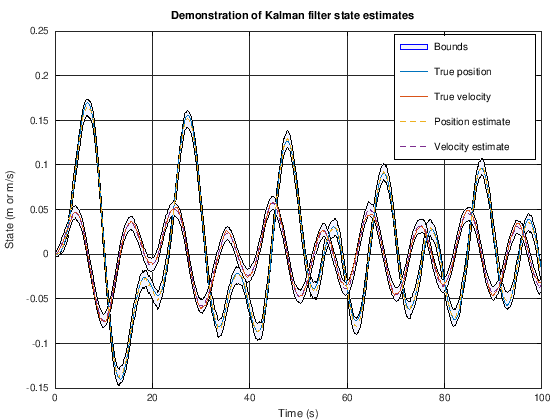

In [3]:
% Plot the states with confidence bounds
t2 = [t fliplr(t)]; % Prepare for plotting bounds via "fill"
x2 = [xhatstore-boundstore fliplr(xhatstore+boundstore)];
h1a = fill(t2,x2(1,:),'b',"FaceAlpha",0.05); hold on; grid on
fill(t2,x2(2,:),'b',"FaceAlpha",0.05); 
h2 = plot(t,x',t,xhatstore','--'); ylim([-0.15 0.25]);
legend([h2;h1a],{'True position','True velocity','Position estimate',...
  'Velocity estimate','Bounds'}); 
title('Demonstration of Kalman filter state estimates    '); 
xlabel('Time (s)'); ylabel('State (m or m/s)'); 

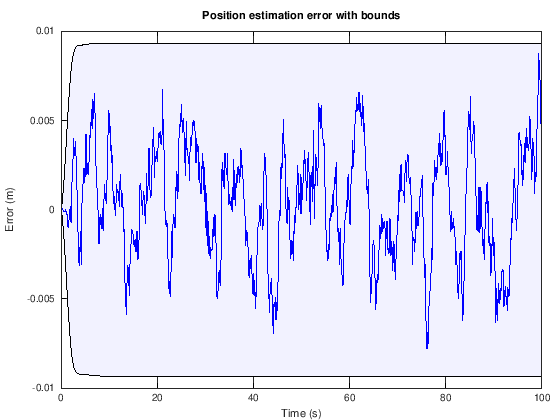

In [4]:
xerr = x - xhatstore; 
fill([t fliplr(t)],[-boundstore(1,:) fliplr(boundstore(1,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerr(1,:),'b');
title('Position estimation error with bounds'); 
xlabel('Time (s)'); ylabel('Error (m)'); 

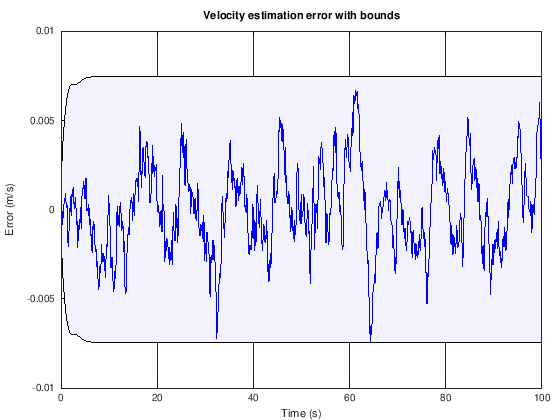

In [5]:
fill([t fliplr(t)],[-boundstore(2,:) fliplr(boundstore(2,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerr(2,:),'b');
title('Velocity estimation error with bounds'); 
xlabel('Time (s)'); ylabel('Error (m/s)'); 

### User workspace
You can enter your own Octave commands into the next cell to query variables, plot results, or anything you like.

In [6]:
% For example, see if (and where) the velocity state is ever outside of the bounds
find(abs(xerr(2,:))>boundstore(2,:))

ans =  645
